# MLP hyperparameter transfer — talk figure

Before / after: residual MLP **without** vs **with** transfer scalings, sweeping $\eta_0$ across several $(L,D)$ sizes.

**Task:** full MNIST (flatten $28\times28\to 784$, 10-way), **1 epoch** per $(\mathrm{model},\,L,\,D,\,\eta_0)$.

Sizes: $(L,D)\in\{(2,128),(3,192),(4,256),(5,384),(6,512),(7,768)\}$.

$\eta_0$ grids:
- **Unscaled:** $10^{-4}\to 5\times 10^{-2}$
- **Transfer-scaled:** $5\times 10^{-3}\to 10^{0}$

## Transfer scalings (scaled model)

With width $D$ and $\sigma = D^{-1/2}$:

| Piece | Weights | Forward scale |
|---|---|---|
| Adam LR | — | $\eta = \eta_0 / \sqrt{D}$ |
| First layer | $W\sim\mathcal{N}(0,\sigma^2)$ | $1/(\sigma\sqrt{n_0})=\sqrt{D/n_0}$ |
| Residual | $W\sim\mathcal{N}(0,1)$ | $(1/L)\,(1/\sqrt{D})$ |
| Last layer | $W\sim\mathcal{N}(0,\sigma^2)$ | $1/(D\sigma)=1/\sqrt{D}$ |

**Baseline (unscaled):** $\eta=\eta_0$, residual $x+W\sigma(x)$, $W\sim\mathcal{N}(0,1)$ (no Kaiming), no extra scales.

Metric: train / val loss after the single epoch. Separate two-panel figures (train top, val bottom).

In [6]:
from __future__ import annotations

import math
import os
import sys
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("OMP_NUM_THREADS", "4")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

REPO = Path("..").resolve()
sys.path[:0] = [str(REPO), str(REPO / "src")]

from cpen.models.base import adam_lr

import scienceplots  # noqa: F401

plt.style.use(["science", "no-latex"])
mpl.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.labelsize": 10,
        "legend.fontsize": 7,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

FIG_DIR = Path("figures/mlp_transfer_talk")
FIG_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cpu")
SEED = 0

SIZES = [(2, 128), (3, 192), (4, 256), (5, 384), (6, 512)]
ETA0_BASELINE = np.geomspace(1e-4, 1e-0, 8)
ETA0_TRANSFER = np.geomspace(5e-3, 1e0, 8)
EPOCHS = 20
BATCH_SIZE = 1024
N_TRAIN: int | None = None  # full MNIST train
N_VAL: int | None = None  # full 10k test

MNIST_ROOT = Path("/scratch/gpfs/BHANIN/jdezoort/datasets/mnist")
MNIST_ROOT.mkdir(parents=True, exist_ok=True)

print(
    f"adam_lr check: η0=0.25, D=256 → {adam_lr(0.25, 256):.6f} "
    f"(expect {0.25 / math.sqrt(256):.6f})"
)
print(f"sizes: {SIZES}")
print(f"η0 baseline: {ETA0_BASELINE[0]:.0e} → {ETA0_BASELINE[-1]:.0e}")
print(f"η0 transfer: {ETA0_TRANSFER[0]:.0e} → {ETA0_TRANSFER[-1]:.0e}")

adam_lr check: η0=0.25, D=256 → 0.015625 (expect 0.015625)
sizes: [(2, 128), (3, 192), (4, 256), (5, 384), (6, 512)]
η0 baseline: 1e-04 → 1e+00
η0 transfer: 5e-03 → 1e+00


## MNIST

Flattened pixels $n_{\mathrm{in}}=784$, $n_{\mathrm{out}}=10$. Full train split; full test split as validation.

In [7]:
def load_mnist(
    root: Path,
    *,
    n_train: int | None = None,
    n_val: int | None = None,
    seed: int = 0,
):
    tfm = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
        ]
    )
    train_ds = datasets.MNIST(root=str(root), train=True, download=True, transform=tfm)
    test_ds = datasets.MNIST(root=str(root), train=False, download=True, transform=tfm)

    def _stack(ds, n: int | None, *, shuffle: bool):
        idx = np.arange(len(ds))
        if shuffle:
            rng = np.random.default_rng(seed)
            rng.shuffle(idx)
        if n is not None:
            idx = idx[:n]
        xs, ys = [], []
        for i in idx:
            x, y = ds[int(i)]
            xs.append(x.view(-1))
            ys.append(y)
        return torch.stack(xs, dim=0), torch.tensor(ys, dtype=torch.long)

    x_tr, y_tr = _stack(train_ds, n_train, shuffle=True)
    x_va, y_va = _stack(test_ds, n_val, shuffle=False)
    return x_tr, y_tr, x_va, y_va


x_tr, y_tr, x_va, y_va = load_mnist(
    MNIST_ROOT, n_train=N_TRAIN, n_val=N_VAL, seed=SEED
)
N_IN = int(x_tr.shape[1])
N_OUT = 10
print(f"train={tuple(x_tr.shape)}  val={tuple(x_va.shape)}  n_in={N_IN}  n_out={N_OUT}")

train=(60000, 784)  val=(10000, 784)  n_in=784  n_out=10


## Models

In [8]:
class BaselineMLP(nn.Module):
    """Unscaled residual MLP: x + W σ(x), η=η₀, W~N(0,1) (no Kaiming / no μP scales)."""

    def __init__(self, n_in: int, n_out: int, depth: int, width: int):
        super().__init__()
        self.depth = depth
        self.width = width
        self.encoder = nn.Linear(n_in, width, bias=False)
        self.layers = nn.ModuleList(
            [nn.Linear(width, width, bias=False) for _ in range(depth)]
        )
        self.decoder = nn.Linear(width, n_out, bias=False)
        for layer in (self.encoder, *self.layers, self.decoder):
            nn.init.normal_(layer.weight, mean=0.0, std=1.0)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.encoder(x)
        for layer in self.layers:
            h = h + layer(self.act(h))
        return self.decoder(h)

    def learning_rate(self, eta0: float) -> float:
        return float(eta0)


class TransferMLP(nn.Module):
    """Transfer-scaled residual MLP.

    σ = 1/√D
      LR:            η = η₀ / √D
      first layer:   W ~ N(0, σ²),  scale 1/(σ √n₀) = √(D/n₀)
      residual:      W ~ N(0, 1),   scale (1/L)(1/√D)
      last layer:    W ~ N(0, σ²),  scale 1/(D σ) = 1/√D
    """

    def __init__(self, n_in: int, n_out: int, depth: int, width: int):
        super().__init__()
        self.depth = depth
        self.width = width
        sigma = 1.0 / math.sqrt(width)

        self.encoder = nn.Linear(n_in, width, bias=False)
        nn.init.normal_(self.encoder.weight, mean=0.0, std=sigma)
        self.encoder_scale = 1.0 / (sigma * math.sqrt(n_in))  # √(D/n₀)

        self.layers = nn.ModuleList(
            [nn.Linear(width, width, bias=False) for _ in range(depth)]
        )
        for layer in self.layers:
            nn.init.normal_(layer.weight, mean=0.0, std=1.0)
        self.residual_scale = (1.0 / depth) * (1.0 / math.sqrt(width))

        self.decoder = nn.Linear(width, n_out, bias=False)
        nn.init.normal_(self.decoder.weight, mean=0.0, std=sigma)
        self.decoder_scale = 1.0 / (width * sigma)  # 1/√D

        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.encoder(x) * self.encoder_scale
        for layer in self.layers:
            h = h + self.residual_scale * layer(self.act(h))
        return self.decoder(h) * self.decoder_scale

    def learning_rate(self, eta0: float) -> float:
        return adam_lr(eta0, self.width)  # η₀ / √D


_m = TransferMLP(N_IN, N_OUT, depth=4, width=256)
_sigma = 1.0 / math.sqrt(256)
assert math.isclose(_m.encoder_scale, 1.0 / (_sigma * math.sqrt(N_IN)))
assert math.isclose(_m.encoder_scale, math.sqrt(256 / N_IN))
assert math.isclose(_m.residual_scale, (1.0 / 4) * (1.0 / math.sqrt(256)))
assert math.isclose(_m.decoder_scale, 1.0 / (256 * _sigma))
assert math.isclose(_m.decoder_scale, 1.0 / math.sqrt(256))
assert math.isclose(_m.learning_rate(0.25), 0.25 / math.sqrt(256))
print(
    f"TransferMLP D=256: σ={_sigma:.4f}, enc={_m.encoder_scale:.4f}, "
    f"res={_m.residual_scale:.6f}, dec={_m.decoder_scale:.4f}, "
    f"lr(η0=0.25)={_m.learning_rate(0.25):.6f}"
)

TransferMLP D=256: σ=0.0625, enc=0.5714, res=0.015625, dec=0.0625, lr(η0=0.25)=0.015625


## Train sweeps (1 epoch each)

In [9]:
@dataclass
class RunResult:
    depth: int
    width: int
    eta0: float
    lr: float
    best_train_loss: float
    best_val_loss: float


def _epoch_loss(model, loader, train: bool, opt=None) -> float:
    model.train(train)
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        if train:
            opt.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        if train:
            loss.backward()
            opt.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / max(n, 1)


def run_one(
    model_cls,
    *,
    depth: int,
    width: int,
    eta0: float,
    x_tr,
    y_tr,
    x_va,
    y_va,
    seed: int,
) -> RunResult:
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = model_cls(N_IN, N_OUT, depth, width).to(DEVICE)
    lr = model.learning_rate(eta0)
    opt = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    train_loader = DataLoader(
        TensorDataset(x_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True, drop_last=False
    )
    val_loader = DataLoader(
        TensorDataset(x_va, y_va), batch_size=BATCH_SIZE, shuffle=False
    )
    tr = float("inf")
    va = float("inf")
    for _ in range(EPOCHS):
        tr = _epoch_loss(model, train_loader, train=True, opt=opt)
        with torch.no_grad():
            va = _epoch_loss(model, val_loader, train=False)
        if not math.isfinite(tr) or not math.isfinite(va):
            break
    return RunResult(depth, width, float(eta0), float(lr), tr, va)


def sweep(model_cls, data, eta0_grid, tag: str) -> list[RunResult]:
    x_tr, y_tr, x_va, y_va = data
    rows: list[RunResult] = []
    for depth, width in SIZES:
        for i, eta0 in enumerate(eta0_grid):
            seed = SEED + 1000 * depth + width + i
            r = run_one(
                model_cls,
                depth=depth,
                width=width,
                eta0=float(eta0),
                x_tr=x_tr,
                y_tr=y_tr,
                x_va=x_va,
                y_va=y_va,
                seed=seed,
            )
            rows.append(r)
            print(
                f"{tag:10s} L={depth} D={width:4d} η0={eta0:.1e} lr={r.lr:.2e}  "
                f"train={r.best_train_loss:.4f} val={r.best_val_loss:.4f}",
                flush=True,
            )
    return rows

In [10]:
data = (x_tr, y_tr, x_va, y_va)
baseline_rows = sweep(BaselineMLP, data, ETA0_BASELINE, tag="baseline")
transfer_rows = sweep(TransferMLP, data, ETA0_TRANSFER, tag="transfer")

baseline   L=2 D= 128 η0=1.0e-04 lr=1.00e-04  train=2229.9679 val=2120.2636
baseline   L=2 D= 128 η0=3.7e-04 lr=3.73e-04  train=542.6674 val=582.7456
baseline   L=2 D= 128 η0=1.4e-03 lr=1.39e-03  train=169.5707 val=269.8919
baseline   L=2 D= 128 η0=5.2e-03 lr=5.18e-03  train=20.6597 val=77.2724
baseline   L=2 D= 128 η0=1.9e-02 lr=1.93e-02  train=6.2862 val=33.1285
baseline   L=2 D= 128 η0=7.2e-02 lr=7.20e-02  train=7.1387 val=10.3092
baseline   L=2 D= 128 η0=2.7e-01 lr=2.68e-01  train=93.6677 val=86.6567
baseline   L=2 D= 128 η0=1.0e+00 lr=1.00e+00  train=6017.2058 val=4709.1867
baseline   L=3 D= 192 η0=1.0e-04 lr=1.00e-04  train=26913.1124 val=25083.1686
baseline   L=3 D= 192 η0=3.7e-04 lr=3.73e-04  train=7796.1330 val=9078.3484
baseline   L=3 D= 192 η0=1.4e-03 lr=1.39e-03  train=1504.5548 val=4939.7252
baseline   L=3 D= 192 η0=5.2e-03 lr=5.18e-03  train=195.8022 val=2428.3767
baseline   L=3 D= 192 η0=1.9e-02 lr=1.93e-02  train=46.3954 val=610.4902
baseline   L=3 D= 192 η0=7.2e-02 lr=

## Talk figures (2× 2-panel)

One figure per regime (unscaled / transfer-scaled). **Train** on top, **val** on bottom. Curves vs $\eta_0$ (baseline $\eta=\eta_0$; transfer $\eta=\eta_0/\sqrt{D}$).

Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.


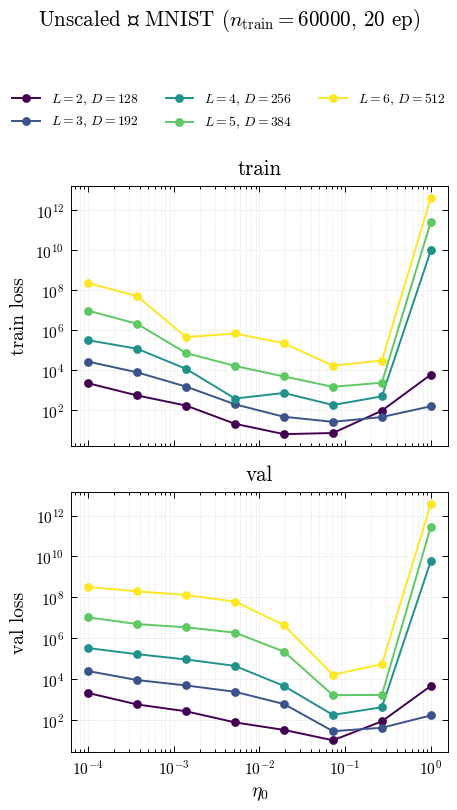

saved figures/mlp_transfer_talk/mlp_transfer_mnist_unscaled.pdf


Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\xb7' [U+b7], substituting with a dummy symbol.


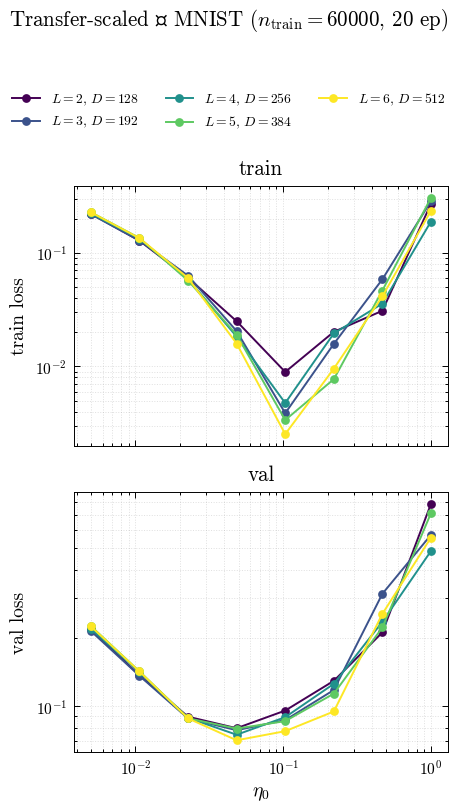

saved figures/mlp_transfer_talk/mlp_transfer_mnist_scaled.pdf


In [11]:
def plot_two_panel(
    rows: list[RunResult],
    *,
    title: str,
    outfile: Path,
):
    cmap = mpl.colormaps["viridis"]
    colors = {
        (L, D): cmap(i / max(len(SIZES) - 1, 1)) for i, (L, D) in enumerate(SIZES)
    }

    fig, axes = plt.subplots(2, 1, figsize=(3.4, 5.2), sharex=True)

    def _draw(ax, metric: str, ylabel: str):
        for L, D in SIZES:
            sub = sorted(
                (r for r in rows if r.depth == L and r.width == D),
                key=lambda r: r.eta0,
            )
            ys = [getattr(r, metric) for r in sub]
            ys_plot = [y if math.isfinite(y) else np.nan for y in ys]
            ax.plot(
                [r.eta0 for r in sub],
                ys_plot,
                "o-",
                ms=3.5,
                color=colors[(L, D)],
                label=rf"$L={L},\,D={D}$",
            )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylabel(ylabel)
        ax.grid(True, which="both", ls=":", alpha=0.4)

    _draw(axes[0], "best_train_loss", r"train loss")
    _draw(axes[1], "best_val_loss", r"val loss")
    axes[0].set_title("train")
    axes[1].set_title("val")
    axes[1].set_xlabel(r"$\eta_0$")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )
    fig.suptitle(title, y=1.12)
    fig.tight_layout()
    fig.savefig(outfile.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(outfile.with_suffix(".png"), bbox_inches="tight")
    plt.show()
    print("saved", outfile.with_suffix(".pdf"))


n_train = int(x_tr.shape[0]) if N_TRAIN is None else N_TRAIN
plot_two_panel(
    baseline_rows,
    title=rf"Unscaled · MNIST ($n_{{\mathrm{{train}}}}={n_train}$, {EPOCHS} ep)",
    outfile=FIG_DIR / "mlp_transfer_mnist_unscaled",
)
plot_two_panel(
    transfer_rows,
    title=rf"Transfer-scaled · MNIST ($n_{{\mathrm{{train}}}}={n_train}$, {EPOCHS} ep)",
    outfile=FIG_DIR / "mlp_transfer_mnist_scaled",
)

## Runtime tip

Full sweep $= 2\times 6\times 8 = 96$ one-epoch runs on full MNIST.